In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB


In [14]:
# Load the dataset
df = pd.read_csv('D:/Product Projects/ml-internship/machine_learning_intership/datasets/spam.csv', encoding='latin-1')
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [15]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.columns = ['label', 'message']
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [16]:
print(df['label'].value_counts())
print(df.isnull().sum())

label
ham     4825
spam     747
Name: count, dtype: int64
label      0
message    0
dtype: int64


In [17]:
#Assigning numerical values to the labels (ham -> 0, spam -> 1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


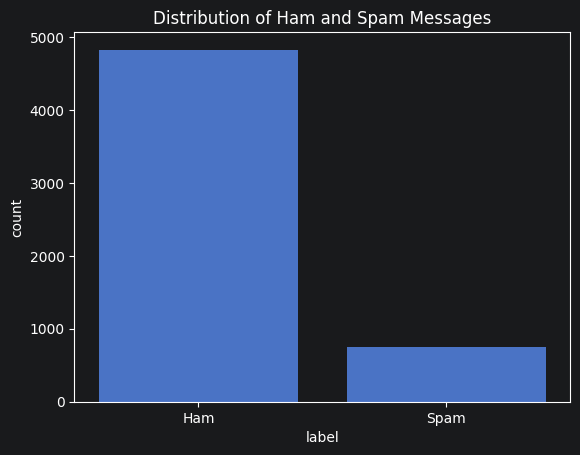

In [18]:
sns.countplot(x='label', data=df)
plt.title('Distribution of Ham and Spam Messages')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
# plt.xlabel('Label (0: Ham, 1: Spam)')
# plt.ylabel('Count')
plt.show()

In [19]:
tfidf = TfidfVectorizer(max_features = 3000,stop_words='english')
X = tfidf.fit_transform(df['message'])
y = df['label']
print(X.shape)

(5572, 3000)


In [20]:
#Splitting the data to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(4457, 3000)
(1115, 3000)


In [21]:
#Training the model using Multinomial Naive Bayes
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [22]:
#Accuracy and Classification Report
y_pred = model.predict(X_test)
print("Accuracy",accuracy_score(y_test, y_pred))
print("\nClassification Report",classification_report(y_test, y_pred))

Accuracy 0.9802690582959641

Classification Report               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       1.00      0.85      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



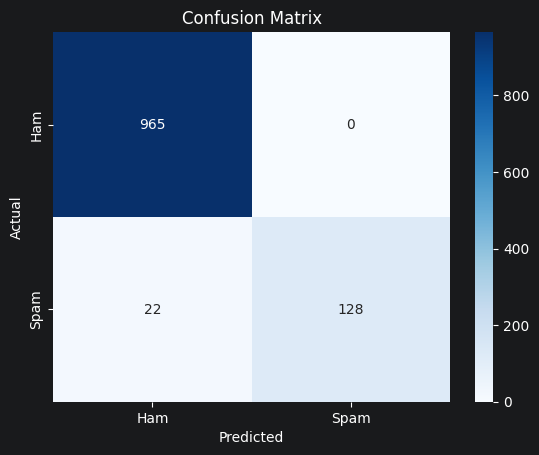

In [23]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
#Saving the model
joblib.dump(model, 'D:/Product Projects/ml-internship/machine_learning_intership/trained_models/spam_classifier_model.pkl')
joblib.dump(tfidf, 'D:/Product Projects/ml-internship/machine_learning_intership/trained_models/spam_classifier_tfidf_vectorizer.pkl')

['D:/Product Projects/ml-internship/machine_learning_intership/trained_models/spam_classifier_tfidf_vectorizer.pkl']